# 02 · 확률 기초 — 이론이 말하는 정답

> Part 2 · *데이터를 보기 전에, 공정한 추첨이라면 무엇이 나와야 하는지 이론으로 계산한다.*

데이터 분석에서 흔한 실수는 **기준선 없이** 관측값을 해석하는 것입니다. "34번이 184번 나왔다"는
많은 걸까요? 그 질문에 답하려면 먼저 *공정한 추첨의 이론값*을 알아야 합니다. 이 노트북은 데이터를
거의 쓰지 않고, 6/45의 확률 구조를 **닫힌 형태(closed-form)**로 유도합니다.

다루는 개념:
- **조합론 & 초기하분포** — 등수별 당첨 확률
- **기대값** — 티켓당 기대 적중 (백테스트의 기준선 0.8)
- **중심극한정리(CLT)** — 왜 6개 합계는 종 모양인가
- **독립 vs 종속 · 복원 vs 비복원** — 로또와 연금복권의 근본적 차이

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.lotto_ds import viz, probability as pb
from src.lotto_ds.cleaning import load_clean

viz.apply_style()

## 1. 조합론과 초기하분포 (Hypergeometric)

45개 중 6개가 당첨입니다. 내가 6개를 고를 때 정확히 $k$개가 맞을 확률은 **초기하분포**를 따릅니다.

$$P(K=k)=\frac{\binom{6}{k}\binom{45-6}{\,6-k}}{\binom{45}{6}}$$

전체 경우의 수 $\binom{45}{6}$을 계산하고 등수별 확률을 구합니다.

In [2]:
from math import comb
print(f"전체 조합 수 C(45,6) = {comb(45,6):,}")
print()
print(f"{'맞춘 개수':>8} {'확률':>14} {'1 in N':>14}")
for row in pb.prize_tier_table():
    print(f"{row['matches']:>8} {row['probability']:>14.3e} {row['one_in']:>14,.0f}")

전체 조합 수 C(45,6) = 8,145,060

   맞춘 개수             확률         1 in N
       6      1.228e-07      8,145,060
       5      2.873e-05         34,808
       4      1.365e-03            733
       3      2.244e-02             45


1등(6개)은 약 **814만 분의 1**. 이 숫자는 데이터가 아니라 순수 조합론에서 나옵니다.

## 2. 기대값 — 백테스트의 기준선

티켓당 기대 적중 개수는 초기하분포의 평균입니다.

$$E[K]=n\cdot\frac{K}{N}=6\cdot\frac{6}{45}=0.8$$

**어떤 번호를 고르든** 이 값은 변하지 않습니다. 09번 백테스트에서 모든 전략이 0.8에 붙는 이유입니다.

In [3]:
print("이론적 티켓당 기대 적중 E[K] =", pb.expected_matches())

이론적 티켓당 기대 적중 E[K] = 0.8


## 3. 왜 합계는 종 모양인가 — 중심극한정리

6개 번호의 합계 평균과 분산은 **비복원 추출** 공식으로 정확히 계산됩니다.

$$\mu=n\frac{N+1}{2}=138,\qquad \sigma^2=n\frac{(N+1)(N-n)}{12}$$

여기서 $(N-n)$ 항이 **유한모집단 보정**(=비복원 종속성)입니다. 이론값을 관측 합계 분포와 겹쳐 봅니다.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


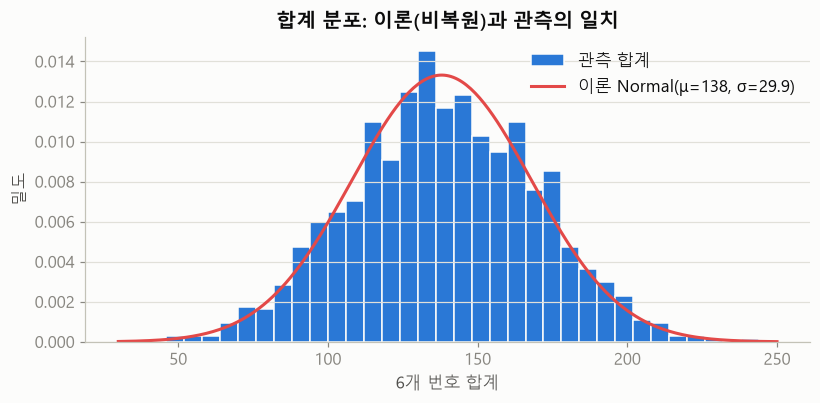

이론: μ=138.0, σ=29.95   관측: μ=138.29, σ=30.78
→ 이론 σ와 관측 σ가 거의 일치. 합계는 사실상 '독립 근사 + CLT'가 예측한 정규 분포.


In [4]:
from scipy import stats
th = pb.sum_theory()
draws = load_clean("draws")
obs_sum = draws[[f"win{i}" for i in range(1,7)]].to_numpy(int).sum(axis=1)

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.hist(obs_sum, bins=range(40, 245, 6), density=True, color=viz.CAT[0],
        edgecolor=viz.INK["surface"], linewidth=1.0, label="관측 합계")
xs = np.linspace(30, 250, 300)
ax.plot(xs, stats.norm.pdf(xs, th.mean, th.std), color=viz.CAT[5], lw=2,
        label=f"이론 Normal(μ={th.mean:.0f}, σ={th.std:.1f})")
ax.set_title("합계 분포: 이론(비복원)과 관측의 일치")
ax.set_xlabel("6개 번호 합계"); ax.set_ylabel("밀도"); ax.legend(frameon=False)
viz.savefig(fig, "02_sum_theory.png"); plt.show()

print(f"이론: μ={th.mean:.1f}, σ={th.std:.2f}   관측: μ={obs_sum.mean():.2f}, σ={obs_sum.std():.2f}")
print("→ 이론 σ와 관측 σ가 거의 일치. 합계는 사실상 '독립 근사 + CLT'가 예측한 정규 분포.")

⚠️ **흔한 함정**: "합계가 138 근처에 몰리니 138짜리 조합을 사면 유리하다"는 착각. 합계가 몰리는 건
*그 합을 만드는 조합 수가 많기 때문*이지, 특정 조합의 당첨 확률이 높아서가 아닙니다. 모든 개별 조합은
정확히 같은 확률(1/8,145,060)입니다.

## 4. 독립 vs 종속 — 로또와 연금복권의 근본 차이

이 절이 두 복권을 함께 다루는 **유일하고 핵심적인 이유**입니다.

| | 로또 6/45 | 연금복권 자릿수 |
|---|---|---|
| 추출 | **비복원** (한 번 뽑힌 번호 제외) | **복원** (각 자리 독립적으로 0–9) |
| 한 추첨 내 | 번호끼리 **음의 상관** (종속) | 자리끼리 **독립** |
| 한 칸의 분포 | 정렬 위치별로 **비균등** | 각 자리 정확히 **Uniform{0–9}** |

비복원 추출의 지표변수 공분산은 항상 **음수**입니다:
$$\mathrm{Cov}(\mathbb{1}_i,\mathbb{1}_j)=-\frac{p(1-p)}{N-1}<0$$

In [5]:
print(f"로또 두 번호 간 지표 공분산 = {pb.within_draw_covariance():.6f}  (음수 → 종속)")
print(f"연금 두 자리 간 공분산      = 0.0            (독립, 복원 추출)")

로또 두 번호 간 지표 공분산 = -0.002626  (음수 → 종속)
연금 두 자리 간 공분산      = 0.0            (독립, 복원 추출)


### 시각적 대비: 정렬 위치의 분포 vs 자릿수 분포
로또에서 "가장 작은 번호(1st order statistic)"는 균등이 **아닙니다**(작은 값 쪽으로 치우침).
반면 연금복권의 각 자리는 정확히 균등합니다.

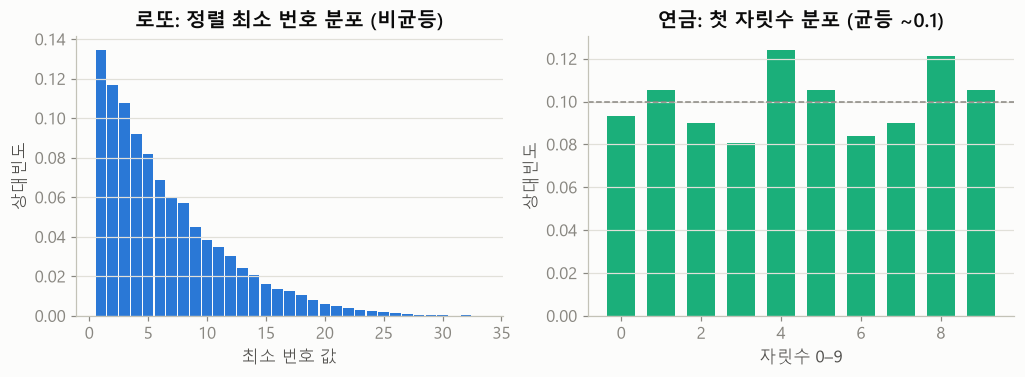

→ 같은 '복권'이라도 표본추출 구조가 다르면 통계적 성질이 근본적으로 달라집니다.
  이것이 데이터를 분석하기 전에 '데이터 생성 과정(DGP)'을 이해해야 하는 이유입니다.


In [6]:
import pandas as pd

mins = pb.simulate_position_marginal(trials=15000)          # 로또 최소 번호(정렬 1위)
pension = load_clean("pension_draws")
digit1 = pd.to_numeric(pension["n1"], errors="coerce").dropna().astype(int)  # 연금 첫 자리

fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
vc = pd.Series(mins).value_counts(normalize=True).sort_index()
axes[0].bar(vc.index, vc.values, color=viz.CAT[0], width=0.9)
axes[0].set_title("로또: 정렬 최소 번호 분포 (비균등)")
axes[0].set_xlabel("최소 번호 값"); axes[0].set_ylabel("상대빈도")

dc = digit1.value_counts(normalize=True).reindex(range(10), fill_value=0).sort_index()
axes[1].bar(dc.index, dc.values, color=viz.CAT[1], width=0.7)
axes[1].axhline(0.1, ls="--", color=viz.INK["muted"], lw=1)
axes[1].set_title("연금: 첫 자릿수 분포 (균등 ~0.1)")
axes[1].set_xlabel("자릿수 0–9"); axes[1].set_ylabel("상대빈도")
viz.savefig(fig, "02_independence_contrast.png"); plt.show()

print("→ 같은 '복권'이라도 표본추출 구조가 다르면 통계적 성질이 근본적으로 달라집니다.")
print("  이것이 데이터를 분석하기 전에 '데이터 생성 과정(DGP)'을 이해해야 하는 이유입니다.")

### 정리
- 등수 확률·기대값·합계 분포는 **데이터 없이** 이론으로 정확히 나온다.
- 관측이 이 이론과 얼마나 맞는지가 이후 모든 검정의 뼈대다.
- 로또(비복원·종속) vs 연금(복원·독립)의 대비는 *표본추출 구조가 통계를 지배*함을 보여준다.
- 다음: **03 · EDA** — 이론을 데이터로 확인한다.